In [1]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn joblib matplotlib python-dotenv requests pandas numpy

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()  # readsthe .env file

KEY = os.getenv("WEATHER_AI_KEY")
HEADERS = {"Authorization": f"Bearer {KEY}"}
BASE_URL = "https://api.weather-ai.co"

print("Key loaded:", KEY is not None)

Key loaded: True


In [3]:
params = {
    "lat": -1.2921,
    "lon": 36.8219,
    "days": 7,
    "ai": "false",       
    "units": "metric"
}

response = requests.get(f"{BASE_URL}/v1/daily", headers=HEADERS, params=params)

print("Status code:", response.status_code)
print("Response keys:", response.json().keys())

Status code: 200
Response keys: dict_keys(['location', 'current', 'hourly', 'daily', 'client_geo'])


In [4]:
data = response.json()

import json
print(json.dumps(data, indent=2))

{
  "location": {
    "lat": -1.3005272,
    "lon": 36.824646,
    "timezone": "Africa/Nairobi",
    "requested_lat": -1.2921,
    "requested_lon": 36.8219,
    "country": "KE"
  },
  "current": {
    "time": "2026-06-06T00:15",
    "temperature": 16.8,
    "wind_speed": 5.7,
    "wind_direction": 55,
    "condition_code": "3",
    "icon": "https://cdn.weather-ai.co/icons/default/3_overcast_night.svg",
    "icon_path": "icons/weather/png/wmo-3-night-128.png"
  },
  "hourly": [
    {
      "time": "2026-06-06T00:00",
      "temperature": 17,
      "precipitation_probability": 12,
      "wind_speed": 6.2,
      "condition_code": "3",
      "icon": "https://cdn.weather-ai.co/icons/default/3_overcast_night.svg",
      "humidity": 83,
      "feels_like": 17.4,
      "wind_gust": 11.9,
      "uv_index": 0,
      "icon_path": "icons/weather/png/wmo-3-night-128.png"
    },
    {
      "time": "2026-06-06T01:00",
      "temperature": 16.2,
      "precipitation_probability": 23,
      "wind_spee

## API Response Structure

The `/v1/daily` endpoint returns a `forecast` array where each element represents one day.
Key fields available:
- `date` — ISO date string
- `temp_max`, `temp_min` — daily temperature range in °C
- `precipitation_mm` — expected rainfall in millimetres
- `humidity` — relative humidity percentage
- `wind_speed_kmh` — wind speed
- `uv_index` — UV radiation index



In [5]:
daily_data = data.get("daily") or data.get("forecast", [])

df = pd.DataFrame(daily_data)
print(df.shape)
df.head()

print(df.isnull().sum())
print(df.dtypes)

(7, 11)
date                         0
temp_min                     0
temp_max                     0
precipitation_sum            0
sunrise                      0
sunset                       0
condition_code               0
icon                         0
precipitation_probability    0
wind_max                     0
icon_path                    0
dtype: int64
date                             str
temp_min                     float64
temp_max                     float64
precipitation_sum            float64
sunrise                          str
sunset                           str
condition_code                   str
icon                             str
precipitation_probability      int64
wind_max                     float64
icon_path                        str
dtype: object


In [6]:
# The exact column names the API returns
print(df.columns.tolist())
print(df.head(2))

['date', 'temp_min', 'temp_max', 'precipitation_sum', 'sunrise', 'sunset', 'condition_code', 'icon', 'precipitation_probability', 'wind_max', 'icon_path']
         date  temp_min  temp_max  precipitation_sum           sunrise  \
0  2026-06-06      16.1      24.9                1.3  2026-06-06T06:29   
1  2026-06-07      15.3      24.9                0.8  2026-06-07T06:30   

             sunset condition_code  \
0  2026-06-06T18:32             51   
1  2026-06-07T18:33             51   

                                                icon  \
0  https://cdn.weather-ai.co/icons/default/51_dri...   
1  https://cdn.weather-ai.co/icons/default/51_dri...   

   precipitation_probability  wind_max                             icon_path  
0                         47      12.2  icons/weather/png/wmo-51-day-128.png  
1                         52      13.1  icons/weather/png/wmo-51-day-128.png  


## There are no null columns.

In [7]:
import os
os.makedirs("../assets", exist_ok=True)
print("Assets folder ready.")

Assets folder ready.


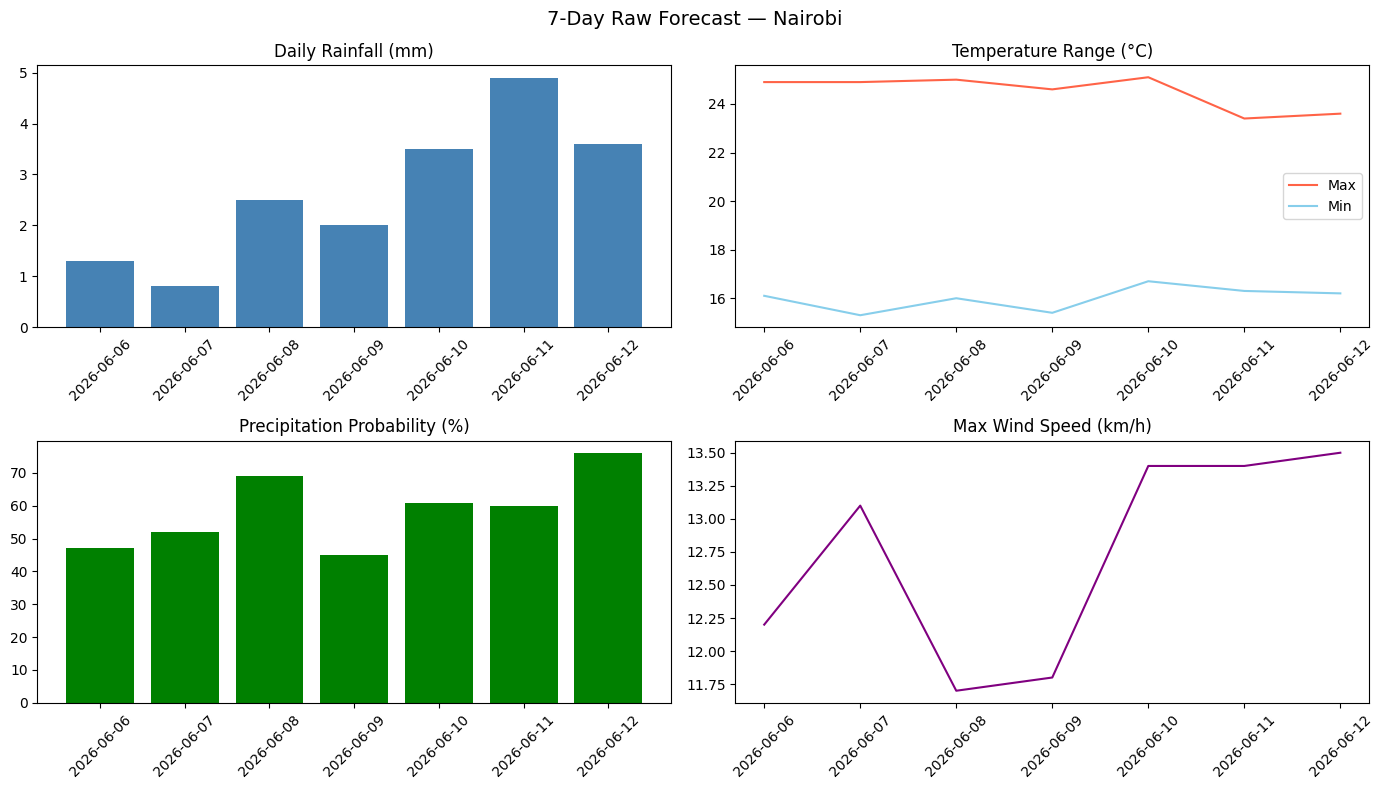

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("7-Day Raw Forecast — Nairobi", fontsize=14)

axes[0,0].bar(df["date"], df["precipitation_sum"], color="steelblue")
axes[0,0].set_title("Daily Rainfall (mm)")
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].plot(df["date"], df["temp_max"], color="tomato", label="Max")
axes[0,1].plot(df["date"], df["temp_min"], color="skyblue", label="Min")
axes[0,1].set_title("Temperature Range (°C)")
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=45)

axes[1,0].bar(df["date"], df["precipitation_probability"], color="green")
axes[1,0].set_title("Precipitation Probability (%)")
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].plot(df["date"], df["wind_max"], color="purple")
axes[1,1].set_title("Max Wind Speed (km/h)")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../assets/raw_forecast.png", dpi=150)
plt.show()

## Feature Engineering

Raw forecast fields alone are not sufficient for crop risk modeling. We derive agronomic
features based on established thresholds from agricultural research.

In [9]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Temperature features
    df["temp_range"]   = df["temp_max"] - df["temp_min"]
    df["heat_stress"]  = (df["temp_max"] > 32).astype(int)
    df["cold_stress"]  = (df["temp_min"] < 10).astype(int)
    df["optimal_temp"] = ((df["temp_max"] >= 20) & (df["temp_max"] <= 30)).astype(int)

    # Rainfall features — using correct column name
    df["cumulative_rain"] = df["precipitation_sum"].cumsum()
    df["drought_flag"]    = (df["precipitation_sum"] < 1.0).astype(int)
    df["flood_risk_flag"] = (df["precipitation_sum"] > 30).astype(int)

    # Rain probability risk
    df["high_rain_prob"]  = (df["precipitation_probability"] > 70).astype(int)

    # Wind — using correct column name
    df["high_wind"]       = (df["wind_max"] > 40).astype(int)

    # Composite stress score
    df["crop_stress_score"] = (
        df["heat_stress"]      * 25 +
        df["cold_stress"]      * 20 +
        df["flood_risk_flag"]  * 20 +
        df["drought_flag"]     * 15 +
        df["high_rain_prob"]   * 10 +
        df["high_wind"]        * 10
    ).clip(0, 100)

    df["planting_window"] = (df["crop_stress_score"] < 20).astype(int)

    return df

df_features = engineer_features(df)
df_features[["date","temp_range","heat_stress","drought_flag",
             "flood_risk_flag","crop_stress_score","planting_window"]]

,date,temp_range,heat_stress,drought_flag,flood_risk_flag,crop_stress_score,planting_window
0,2026-06-06,8.8,0,0,0,0,1
1,2026-06-07,9.6,0,1,0,15,1
2,2026-06-08,9.0,0,0,0,0,1
3,2026-06-09,9.2,0,0,0,0,1
4,2026-06-10,8.4,0,0,0,0,1
5,2026-06-11,7.1,0,0,0,0,1
6,2026-06-12,7.4,0,0,0,10,1


In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib

np.random.seed(42)
N = 2000

temp_max      = np.random.uniform(15, 40, N)
temp_min      = np.random.uniform(5, 25, N)
precipitation = np.random.exponential(5, N)
precip_prob   = np.random.uniform(0, 100, N)
wind_max      = np.random.uniform(0, 60, N)

# Labels
risk = np.zeros(N, dtype=int)
risk[temp_max > 35]      += 1
risk[temp_max > 38]      += 1
risk[temp_min < 8]       += 1
risk[precipitation > 40] += 1
risk[precipitation > 60] += 1
risk[precip_prob > 80]   += 1
risk[wind_max > 45]      += 1
risk = np.clip(risk, 0, 2)

X = np.column_stack([temp_max, temp_min, precipitation, precip_prob, wind_max])
y = risk

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test),
      target_names=["Low Risk", "Moderate Risk", "High Risk"]))

               precision    recall  f1-score   support

     Low Risk       1.00      1.00      1.00       163
Moderate Risk       0.99      1.00      1.00       143
    High Risk       1.00      0.99      0.99        94

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400



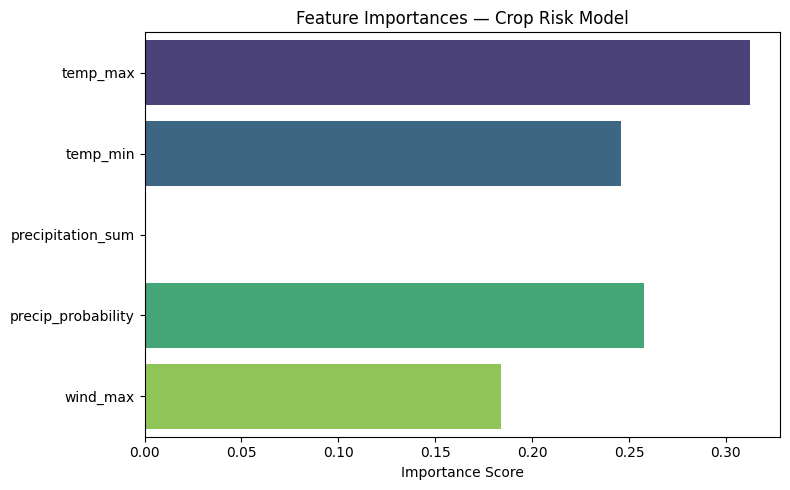

In [11]:
feature_names = ["temp_max", "temp_min", "precipitation_sum", "precip_probability", "wind_max"]
importances   = model.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, hue=feature_names, palette="viridis", legend=False)
plt.title("Feature Importances — Crop Risk Model")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../assets/feature_importances.png", dpi=150)
plt.show()

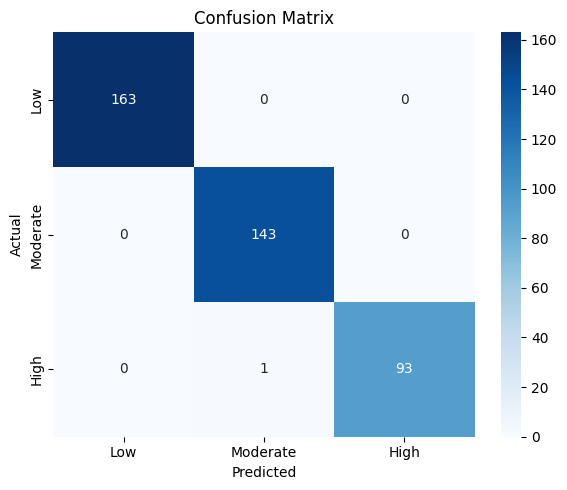

In [12]:
cm = confusion_matrix(y_test, model.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Moderate","High"],
            yticklabels=["Low","Moderate","High"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../assets/confusion_matrix.png", dpi=150)
plt.show()

In [13]:
FEATURE_COLS = ["temp_max","temp_min","precipitation_sum","precipitation_probability","wind_max"]

X_real         = df_features[FEATURE_COLS].values
predictions    = model.predict(X_real)
probabilities  = model.predict_proba(X_real)

LABELS = ["Low Risk", "Moderate Risk", "High Risk"]
df_features["risk_label"]       = [LABELS[p] for p in predictions]
df_features["risk_confidence"]  = probabilities.max(axis=1).round(2)

df_features[["date","crop_stress_score","risk_label","risk_confidence"]]

,date,crop_stress_score,risk_label,risk_confidence
0,2026-06-06,0,Low Risk,1.0
1,2026-06-07,15,Low Risk,1.0
2,2026-06-08,0,Low Risk,1.0
3,2026-06-09,0,Low Risk,1.0
4,2026-06-10,0,Low Risk,1.0
5,2026-06-11,0,Low Risk,1.0
6,2026-06-12,10,Low Risk,1.0


In [14]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/risk_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [15]:
import urllib.request

# Using a publicly accessible aerial farm image
url = "https://images.unsplash.com/photo-1500382017468-9049fed747ef?w=1280"
urllib.request.urlretrieve(url, "sample_farm2.jpg")
print("Image downloaded successfully.")

Image downloaded successfully.


In [16]:
with open("sample_farm2.jpg", "rb") as f:
    img_bytes = f.read()

response = requests.post(
    f"{BASE_URL}/v1/trees/analyze",
    headers=HEADERS,
    files={"image": ("farm.jpg", img_bytes, "image/jpeg")},
    data={"county": "Nairobi", "landAcres": "2.5"}
)

tree_data = response.json()
print(json.dumps(tree_data, indent=2))

{
  "analysis_id": "2f2pArvPI2UJ7av5EDoP",
  "timestamp": "2026-06-05T21:18:30.266Z",
  "farmer_id": null,
  "county": "Nairobi",
  "location": null,
  "land_acres": 2.5,
  "total_tree_count": 0,
  "tree_density_per_acre": null,
  "confidence_score": 0,
  "canopy_coverage_pct": null,
  "tree_health": {
    "healthy": 0,
    "needs_care": 0,
    "needs_replacement": 0
  },
  "low_confidence": true,
  "tree_species_guess": null,
  "image_perspective": null,
  "coverage_estimate": null,
  "cv_count_used": true,
  "observations": [],
  "recommendations": [],
  "original_image_url": "https://storage.googleapis.com/weatherai-api.firebasestorage.app/tree_analyses/w35KSE6xTVVEbF6Pebl8zc1dDq72/1780694309735_original.jpg",
  "overlay_image_url": null,
  "cv_debug": null,
  "gemini_error": "GEMINI_API_KEY not configured in functions environment"
}


In [17]:
health = tree_data.get("tree_health", {})

print("Tree analysis result:")
print(json.dumps(tree_data, indent=2))
print("\nHealth data:", health)

# Only plot if we have non-zero values
health_values = list(health.values())
health_labels = list(health.keys())

if sum(health_values) > 0:
    plt.figure(figsize=(5, 5))
    plt.pie(health_values, labels=health_labels,
            colors=["green", "orange", "red"], autopct="%1.0f%%")
    plt.title(f"Canopy Health — {tree_data.get('total_tree_count', 0)} trees detected")
    plt.savefig("../assets/canopy_health.png", dpi=150)
    plt.show()
    print("Chart saved successfully.")
else:
    print("No trees detected in this image — skipping pie chart.")
    print("Try a clearer aerial/drone farm image for better results.")

Tree analysis result:
{
  "analysis_id": "2f2pArvPI2UJ7av5EDoP",
  "timestamp": "2026-06-05T21:18:30.266Z",
  "farmer_id": null,
  "county": "Nairobi",
  "location": null,
  "land_acres": 2.5,
  "total_tree_count": 0,
  "tree_density_per_acre": null,
  "confidence_score": 0,
  "canopy_coverage_pct": null,
  "tree_health": {
    "healthy": 0,
    "needs_care": 0,
    "needs_replacement": 0
  },
  "low_confidence": true,
  "tree_species_guess": null,
  "image_perspective": null,
  "coverage_estimate": null,
  "cv_count_used": true,
  "observations": [],
  "recommendations": [],
  "original_image_url": "https://storage.googleapis.com/weatherai-api.firebasestorage.app/tree_analyses/w35KSE6xTVVEbF6Pebl8zc1dDq72/1780694309735_original.jpg",
  "overlay_image_url": null,
  "cv_debug": null,
  "gemini_error": "GEMINI_API_KEY not configured in functions environment"
}

Health data: {'healthy': 0, 'needs_care': 0, 'needs_replacement': 0}
No trees detected in this image — skipping pie chart.
Try a